## Pergunta de Pesquisa

Filmes com maior bilheteria doméstica tendem a ter maior bilheteria mundial?

## Descrição dos Dados

Para responder a essa pergunta, utilizamos um dataset contendo informações financeiras sobre filmes. As principais colunas analisadas são:

- **Domestic Sales**: representa a bilheteria arrecadada no mercado doméstico.
- **International Sales**: representa a bilheteria arrecadada fora do mercado doméstico.
- **Worldwide Sales**: corresponde à soma das bilheterias doméstica e internacional, indicando o total arrecadado globalmente.
- **Domestic Opening**: refere-se à arrecadação do filme em seu fim de semana de estreia no mercado doméstico.

## Hipótese

A hipótese é que filmes com maiores valores em **Domestic Sales** tendem também a apresentar maiores valores em **Worldwide Sales**, indicando uma possível correlação positiva entre essas variáveis.

## Observações

Além disso, a coluna **Domestic Opening** pode ser utilizada para extrair insights adicionais, como o impacto da estreia no desempenho total do filme. Filmes com uma abertura forte podem ter maior visibilidade e, consequentemente, maior arrecadação ao longo do tempo.

## Objetivo

O objetivo da análise é verificar a existência e a intensidade da relação entre a bilheteria doméstica e a bilheteria mundial.

In [2]:
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

handle = "sanjeetsinghnaik/top-1000-highest-grossing-movies"
file_path = "Highest Holywood Grossing Movies.csv"

df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)

list(df.columns)


e:\Cesar\Python\Estatística\TrabalhoEstatistica\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\User\AppData\Local\Temp\ipykernel_3180\1179833260.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)


['Unnamed: 0',
 'Title',
 'Movie Info',
 'Year',
 'Distributor',
 'Budget (in $)',
 'Domestic Opening (in $)',
 'Domestic Sales (in $)',
 'International Sales (in $)',
 'World Wide Sales (in $)',
 'Release Date',
 'Genre',
 'Running Time',
 'License']

## Verificação de Dados Faltantes

Antes de iniciar a análise, é importante verificar se existem dados faltantes nas colunas utilizadas:

- **Domestic Sales**
- **International Sales**
- **Worldwide Sales**
- **Domestic Opening**

A presença de valores nulos pode impactar os resultados da análise, por isso essa etapa é necessária para garantir a qualidade dos dados.

In [3]:
df_filtrado = df[['Title','Domestic Sales (in $)','International Sales (in $)','World Wide Sales (in $)','Domestic Opening (in $)']]

df_filtrado.dtypes


Title                           str
Domestic Sales (in $)         int64
International Sales (in $)    int64
World Wide Sales (in $)       int64
Domestic Opening (in $)         str
dtype: object

É possivel notar que Domestic Opening esta no formato string então é preciso converte ele para um formato de inteiro como as estão nas demais colunas !

In [4]:
print(df_filtrado['Domestic Opening (in $)'])

0       77025481
1      357115007
2      134100226
3       28638131
4      247966675
         ...    
995     35648740
996     29651193
997     15190758
998     20574802
999     30429860
Name: Domestic Opening (in $), Length: 1000, dtype: str


In [5]:
(~df_filtrado['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$')).any()


np.True_

** Aparti dessa analise de regex é possivel notar que existe colunas em Domectic Opeing que contem caracteres diferentes de numeros, o que indica possíveis problemas.

In [6]:
df.loc[~df['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$'),['Title', 'Domestic Opening (in $)']]

,Title,Domestic Opening (in $)
95,"Hi, Mom",2 hr 8 min
148,Detective Chinatown 3,February 12 2021 (China)
279,Moon Man,2 hr 2 min
285,Dying to Survive,1 hr 57 min
317,"My People, My Homeland",2 hr 33 min
344,Gone with the Wind,December 15 1939 (Domestic)
401,Hello Mr. Billionaire,1 hr 58 min
467,Never Say Die,1 hr 40 min
482,Crazy Alien,1 hr 56 min
615,Bambi,August 21 1942 (Domestic)


In [7]:
df.loc[~df['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$'),['Title', 'Domestic Opening (in $)']].shape[0]

28

## Tratamento de Valores Inconsistentes

A partir da análise utilizando expressões regulares (regex), foi identificado que a coluna **Domestic Opening (in $)** contém valores que não seguem o padrão esperado de dados numéricos.

Foram encontrados **28 registros** com valores inconsistentes, incluindo informações como tempo de duração do filme (ex: "2 hr 8 min") e datas de lançamento, o que indica um erro ou inconsistência no dataset.

Esses valores não são relevantes para a análise proposta e podem comprometer os resultados estatísticos.

## Decisão de Tratamento

Dado que a quantidade de registros inválidos é relativamente pequena em relação ao total de dados, a estratégia adotada será a **remoção dessas linhas** do DataFrame.

Essa abordagem garante que a análise seja realizada apenas com dados válidos e confiáveis, sem introduzir distorções nos resultados.

In [8]:
df_filtrado = df_filtrado[df_filtrado['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$')]

(~df_filtrado['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$')).any()

np.False_

In [9]:
print("Antes:", df.shape[0])
print("Depois:", df_filtrado.shape[0])

Antes: 1000
Depois: 972


## Remoção de Dados Inconsistentes

Após a identificação de valores inconsistentes na coluna **Domestic Opening (in $)**, foi realizada a remoção dessas entradas do DataFrame.

A remoção desses registros garante que o conjunto de dados utilizado seja composto apenas por valores válidos e adequados para análise.

In [10]:
df_filtrado['Domestic Opening (in $)'] = df_filtrado['Domestic Opening (in $)'].astype('int64')

df_filtrado.dtypes

Title                           str
Domestic Sales (in $)         int64
International Sales (in $)    int64
World Wide Sales (in $)       int64
Domestic Opening (in $)       int64
dtype: object

In [11]:
cols = ['Domestic Sales (in $)','International Sales (in $)','World Wide Sales (in $)','Domestic Opening (in $)']
(df_filtrado[cols] < 0).any()

Domestic Sales (in $)         False
International Sales (in $)    False
World Wide Sales (in $)       False
Domestic Opening (in $)       False
dtype: bool

## Verificação de Valores Negativos

Foi realizada a verificação de valores negativos nas principais colunas numéricas do dataset.

Não foram encontrados valores negativos, portanto não foi necessário realizar tratamento adicional.

In [12]:
df_filtrado.describe()

,Domestic Sales (in $),International Sales (in $),World Wide Sales (in $),Domestic Opening (in $)
count,9.720000e+02,9.720000e+02,9.720000e+02,9.720000e+02
mean,1.622744e+08,2.639542e+08,4.264058e+08,4.269505e+07
std,1.169126e+08,2.145428e+08,3.080309e+08,3.926199e+07
min,1.805800e+04,2.450000e+07,1.799689e+08,7.456000e+03
25%,9.464145e+07,1.310459e+08,2.280909e+08,1.997578e+07
50%,1.328338e+08,1.932899e+08,3.215637e+08,3.279074e+07
75%,1.937921e+08,3.162972e+08,4.909723e+08,5.458932e+07
max,9.366622e+08,2.138484e+09,2.923706e+09,3.571150e+08


<Axes: >

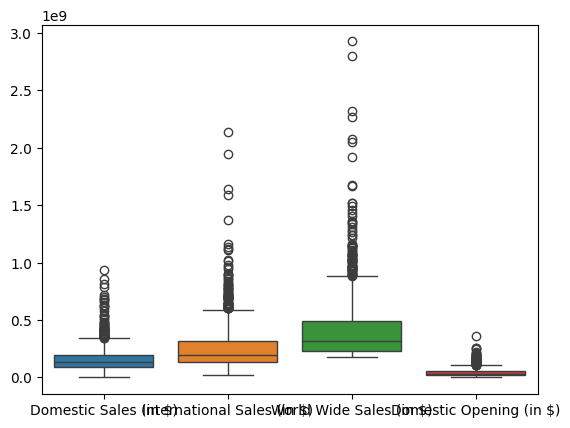

In [13]:
import seaborn as sns
sns.boxplot(data=df_filtrado)

Detectando outliers via z-score

In [14]:
from scipy.stats import zscore

df_filtrado['zscore_worldwide'] = zscore(df_filtrado['World Wide Sales (in $)'])
outliers = df_filtrado[df_filtrado['zscore_worldwide'].abs() > 3]
outliers[['Title', 'World Wide Sales (in $)', 'zscore_worldwide']]

,Title,World Wide Sales (in $),zscore_worldwide
0,Avatar,2923706026,8.111477
1,Avengers: Endgame,2799439100,7.707846
2,Avatar: The Way of Water,2320250281,6.151394
3,Titanic,2264743305,5.971102
4,Star Wars: Episode VII - The Force Awakens,2071310218,5.342812
5,Avengers: Infinity War,2052415039,5.281438
6,Spider-Man: No Way Home,1921847111,4.857341
7,Jurassic World,1671537444,4.044310
8,The Lion King,1663075401,4.016825
9,The Avengers,1520538536,3.553851


# 📊 Análise Exploratória e Relação entre Bilheterias

## Distribuição das Variáveis

Inicialmente, analisamos a distribuição das principais variáveis financeiras dos filmes:

- **Domestic Sales**
- **International Sales**
- **Worldwide Sales**
- **Domestic Opening**

O objetivo é entender como os dados estão distribuídos, identificar possíveis assimetrias (skewness) e detectar a presença de outliers, comuns em datasets de bilheteria devido a grandes blockbusters.

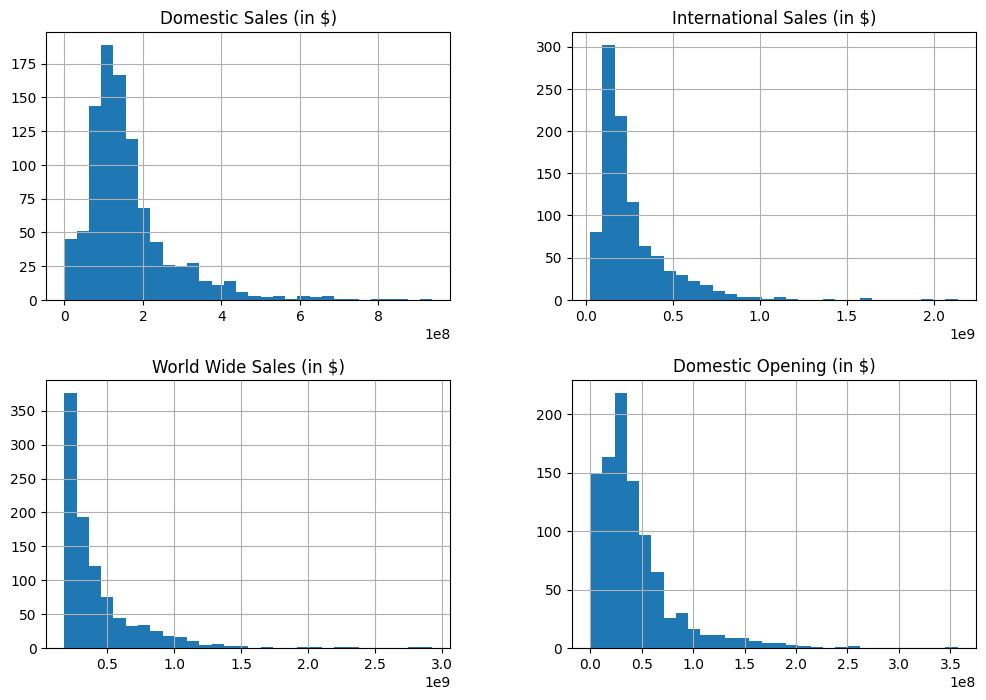

In [15]:
cols = [
    'Domestic Sales (in $)',
    'International Sales (in $)',
    'World Wide Sales (in $)',
    'Domestic Opening (in $)'
]

df_filtrado[cols].hist(bins=30, figsize=(12,8))
plt.show()

## Relação entre Bilheteria Doméstica e Mundial

Em seguida, utilizamos um gráfico de dispersão para visualizar a relação entre Domestic Sales e Worldwide Sales.

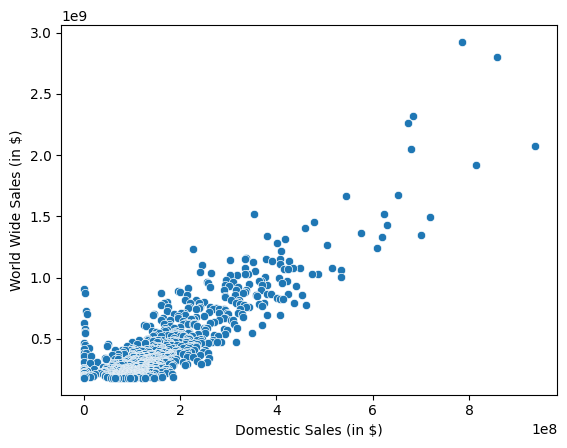

In [16]:
sns.scatterplot(
    data=df_filtrado,
    x='Domestic Sales (in $)',
    y='World Wide Sales (in $)'
)
plt.show()

## Correlação de Pearson (Relação Linear)

Calculamos o coeficiente de correlação de Pearson para medir a força da relação linear entre as variáveis.

In [17]:
pearson_corr, p_value = pearsonr(
    df_filtrado['Domestic Sales (in $)'],
    df_filtrado['World Wide Sales (in $)']
)

print("Pearson:", pearson_corr)
print("p-value:", p_value)

Pearson: 0.8675212745914206
p-value: 1.8823023919624986e-296


Valores próximos de 1 indicam forte correlação positiva
O p-value indica a significância estatística da correlação

## Correlação de Spearman (Relação Monótona)

Para complementar, utilizamos a correlação de Spearman, que é menos sensível a outliers e capta relações monotônicas.

In [18]:
spearman_corr, _ = spearmanr(
    df_filtrado['Domestic Sales (in $)'],
    df_filtrado['World Wide Sales (in $)']
)

print("Spearman:", spearman_corr)

Spearman: 0.7509559310227784


## Matriz de Correlação

Analisamos a correlação entre todas as variáveis numéricas do dataset.

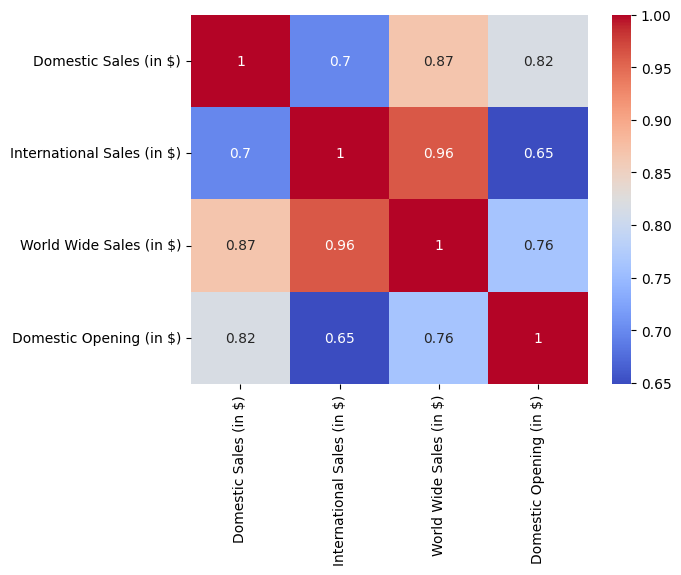

In [19]:
sns.heatmap(
    df_filtrado[cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

Essa visualização permite identificar:

Relações fortes entre variáveis
Possíveis redundâncias (ex: Worldwide já inclui Domestic + International)

## Regressão Linear

Aplicamos uma regressão linear para visualizar a tendência entre as variáveis e entender melhor o comportamento dos dados.

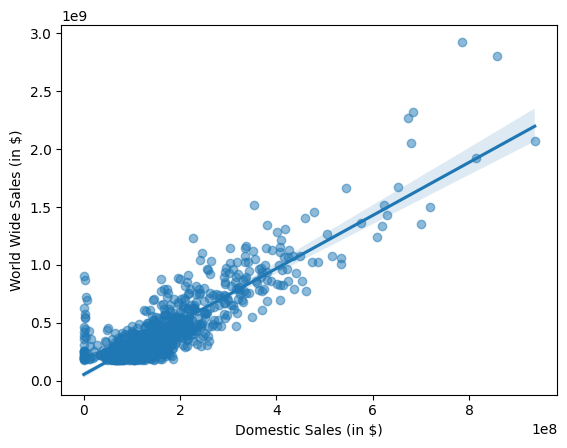

In [20]:
sns.regplot(
    data=df_filtrado,
    x='Domestic Sales (in $)',
    y='World Wide Sales (in $)',
    scatter_kws={'alpha':0.5}
)
plt.show()

## Análise da Proporção Internacional

Criamos a métrica International Ratio, que representa a proporção da bilheteria mundial proveniente do mercado internacional.

In [21]:
df_filtrado['International Ratio'] = (
    df_filtrado['International Sales (in $)'] /
    df_filtrado['World Wide Sales (in $)']
)

df_filtrado

,Title,Domestic Sales (in $),International Sales (in $),World Wide Sales (in $),Domestic Opening (in $),zscore_worldwide,International Ratio
0,Avatar,785221649,2138484377,2923706026,77025481,8.111477,0.731429
1,Avengers: Endgame,858373000,1941066100,2799439100,357115007,7.707846,0.693377
2,Avatar: The Way of Water,684075767,1636174514,2320250281,134100226,6.151394,0.705172
3,Titanic,674292608,1590450697,2264743305,28638131,5.971102,0.702265
4,Star Wars: Episode VII - The Force Awakens,936662225,1134647993,2071310218,247966675,5.342812,0.547792
...,...,...,...,...,...,...,...
995,Sweet Home Alabama,127223418,53399006,180622424,35648740,-0.798329,0.295639
996,Daddy's Home 2,104029443,76584381,180613824,29651193,-0.798356,0.424023
997,Hacksaw Ridge,67209615,113354021,180563636,15190758,-0.798519,0.627779
998,Deja Vu,64038616,116518934,180557550,20574802,-0.798539,0.645329


## Estatísticas do International Ratio

Calculamos a média e o desvio padrão dessa proporção.

In [22]:
mean = df_filtrado['International Ratio'].mean()
std = df_filtrado['International Ratio'].std()

print("Média:", mean)
print("Desvio padrão:", std)

Média: 0.6027747217459826
Desvio padrão: 0.14928359607296088


## Distribuição do International Ratio

Por fim, analisamos a distribuição do International Ratio.

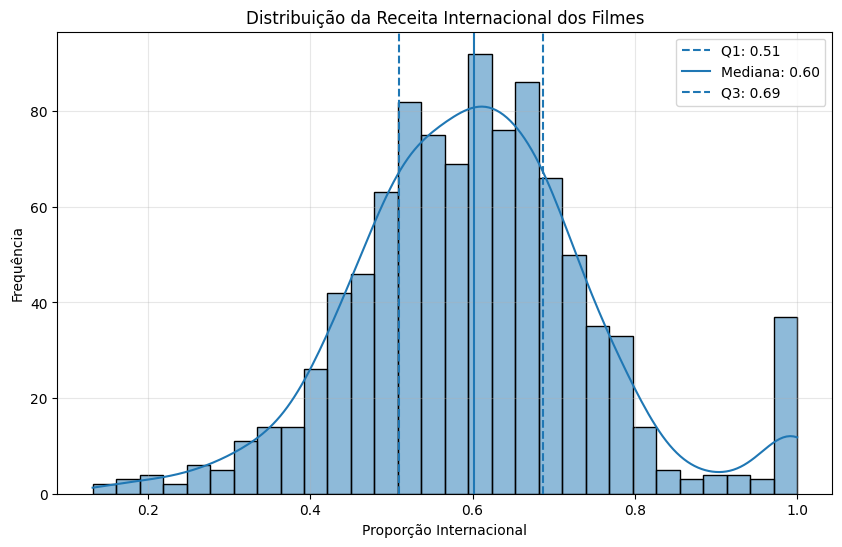

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_filtrado['International Ratio'],
    bins=30,
    kde=True
)

q1 = df_filtrado['International Ratio'].quantile(0.25)
median = df_filtrado['International Ratio'].median()
q3 = df_filtrado['International Ratio'].quantile(0.75)

plt.axvline(q1, linestyle='--', label=f"Q1: {q1:.2f}")
plt.axvline(median, linestyle='-', label=f"Mediana: {median:.2f}")
plt.axvline(q3, linestyle='--', label=f"Q3: {q3:.2f}")

plt.title("Distribuição da Receita Internacional dos Filmes")
plt.xlabel("Proporção Internacional")
plt.ylabel("Frequência")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

A linha em 0.5 representa um equilíbrio entre mercado doméstico e internacional.

Essa análise permite identificar:

Se os filmes tendem a ser mais globais ou domésticos📊 Distribuição da Receita Internacional dos Filmes
📝 Descrição do Gráfico

O gráfico apresenta a distribuição da variável International Ratio, que representa a proporção da bilheteria mundial proveniente do mercado internacional.

O eixo x mostra a proporção internacional (valores entre 0 e 1)
O eixo y representa a frequência de filmes# 📊 Distribuição da Receita Internacional dos Filmes

## 📝 Descrição do Gráfico

O gráfico apresenta a distribuição da variável **International Ratio**, que representa a proporção da bilheteria mundial proveniente do mercado internacional.

- O eixo **x** mostra a proporção internacional (valores entre 0 e 1)
- O eixo **y** representa a frequência de filmes
- A curva suave (KDE) indica a densidade da distribuição
- Linhas verticais destacam:
  - **Q1 (1º quartil): 0.51**
  - **Mediana: 0.60**
  - **Q3 (3º quartil): 0.69**

---

## 📈 Análise dos Resultados

### 🌍 Predominância do mercado internacional

A mediana em **0.60** indica que:

> Mais da metade dos filmes obtém cerca de **60% ou mais da sua receita fora do mercado doméstico**

Isso reforça que o mercado internacional é **o principal motor de receita** da indústria cinematográfica.

---

### 📊 Concentração dos dados

Os quartis mostram que:

- 25% dos filmes têm proporção internacional abaixo de **0.51**
- 50% dos filmes estão entre **0.51 e 0.69**
- 25% estão acima de **0.69**

👉 Isso indica uma **concentração significativa** entre 50% e 70%, mostrando um padrão consistente na indústria.

---

### 🔄 Formato da distribuição

A distribuição apresenta:

- Leve assimetria à direita (*right-skewed*)
- Cauda estendida próxima de **1.0**

Isso sugere que:

- Existem filmes altamente dependentes do mercado internacional
- Alguns casos extremos onde quase toda a receita vem de fora

---

### 🎬 Perfis de filmes identificados

Com base no gráfico, podemos identificar três perfis:

#### 🟢 Filmes equilibrados
- Próximos de **0.5**
- Receita bem distribuída entre doméstico e internacional

#### 🔵 Filmes globais (maioria)
- Entre **0.6 e 0.7**
- Forte presença internacional

#### 🔴 Filmes altamente internacionais
- Acima de **0.8**
- Dependem quase totalmente do mercado externo

---

### ⚠️ Presença de extremos

A pequena concentração próxima de **1.0** indica:

- Filmes com desempenho doméstico baixo
- Ou com forte apelo internacional

---

A curva suave (KDE) indica a densidade da distribuição
Linhas verticais destacam:
Q1 (1º quartil): 0.51
Mediana: 0.60
Q3 (3º quartil): 0.69
📈 Análise dos Resultados
🌍 Predominância do mercado internacional

A mediana em 0.60 indica que:

Mais da metade dos filmes obtém cerca de 60% ou mais da sua receita fora do mercado doméstico

Isso reforça que o mercado internacional é o principal motor de receita da indústria cinematográfica.

📊 Concentração dos dados

Os quartis mostram que:

25% dos filmes têm proporção internacional abaixo de 0.51
50% dos filmes estão entre 0.51 e 0.69
25% estão acima de 0.69

👉 Isso indica uma concentração significativa entre 50% e 70%, mostrando um padrão consistente na indústria.

🔄 Formato da distribuição

A distribuição apresenta:

Leve assimetria à direita (right-skewed)
Cauda estendida próxima de 1.0

Isso sugere que:

Existem filmes altamente dependentes do mercado internacional
Alguns casos extremos onde quase toda a receita vem de fora
🎬 Perfis de filmes identificados

Com base no gráfico, podemos identificar três perfis:

🟢 Filmes equilibrados
Próximos de 0.5
Receita bem distribuída entre doméstico e internacional
🔵 Filmes globais (maioria)
Entre 0.6 e 0.7
Forte presença internacional
🔴 Filmes altamente internacionais
Acima de 0.8
Dependem quase totalmente do mercado externo
⚠️ Presença de extremos

A pequena concentração próxima de 1.0 indica:

Filmes com desempenho doméstico baixo
Ou com forte apelo internacional (ex: mercados asiáticos/europeus)
A existência de diferentes perfis de distribuição de receita

# 🧾 Conclusão da Análise

## 🎯 Pergunta de Pesquisa
Filmes com maior bilheteria doméstica tendem a ter maior bilheteria mundial?

---

## ✅ Resposta

Sim, existe uma forte evidência de que filmes com maior bilheteria doméstica tendem a apresentar maior bilheteria mundial.

---

## 📊 Evidências Estatísticas

- Correlação de Pearson: **0.8675**
- p-value: **~0 (estatisticamente significativo)**
- Correlação de Spearman: **0.7510**

Esses valores indicam uma **forte relação positiva**, tanto linear quanto monotônica, entre as variáveis.

---

## 🧠 Interpretação

### 🔹 Relação não implica causalidade
O sucesso doméstico não causa diretamente o sucesso global, mas ambos são influenciados por fatores como:
- Marketing
- Popularidade
- Distribuição internacional

---

### 🌍 Influência do mercado internacional

A análise do *International Ratio* mostrou que:

- Média ≈ **0.60**
- Ou seja, cerca de **60% da receita vem do mercado internacional**

Isso indica que o mercado internacional é fundamental para o sucesso global.

---

### ⚠️ Impacto dos Outliers

Filmes como Avatar, Avengers: Endgame e Titanic possuem valores extremamente altos e influenciam fortemente a análise.

Isso mostra que:
- A distribuição é assimétrica (right-skewed)
- Poucos filmes dominam a arrecadação global

---

## 🏁 Conclusão Final

Existe uma forte e estatisticamente significativa relação entre a bilheteria doméstica e mundial.

No entanto:
- O desempenho internacional é um fator essencial
- A presença de outliers influencia significativamente os resultados

Portanto, a bilheteria doméstica é um bom indicador, mas não suficiente isoladamente para explicar o sucesso global.

A maioria dos filmes obtém mais de 50% da sua receita no mercado internacional, reforçando a importância da distribuição global na indústria cinematográfica.